# Laboratório Prático - Ambientes Complexos I

---

## Ajustando ambiente

In [1]:
import math
import random

## Motivação

Estudar algoritmos de busca local, como a Subida de Encosta (Hill Climbing) e o Recozimento Simulado (Simulated Annealing), é fundamental na Inteligência Artificial porque eles oferecem abordagens eficientes para problemas complexos de otimização, onde o foco não é o caminho percorrido, mas sim a descoberta do melhor estado final com base em uma função objetivo. Conceitualmente, a busca local navega pelo espaço de estados avaliando vizinhos para encontrar o máximo ou mínimo global, destacando-se por utilizar pouca memória. Como a Subida de Encosta clássica é "gananciosa" e frequentemente fica presa em picos falsos (máximos locais), suas variantes — como a busca estocástica, a de primeira escolha e a com reinício aleatório — introduzem aleatoriedade para escapar dessas armadilhas e aumentar a resiliência do algoritmo. O Recozimento Simulado aprimora essa fuga ao permitir estrategicamente movimentos que temporariamente pioram a avaliação (movimentos para baixo), reduzindo a probabilidade dessas escolhas ruins ao longo do tempo conforme uma "temperatura" diminui, até o sistema estabilizar na solução ideal. O domínio dessas metodologias é indispensável, pois elas não apenas resolvem problemas práticos complexos de engenharia, como o design de circuitos integrados (layout VLSI), o escalonamento de chão de fábrica e a otimização de redes de telecomunicações, mas seus princípios de exploração e descida de gradiente também fundamentam a otimização contínua e convexa, que são a base matemática para resolver problemas cruciais modernos em aprendizado de máquina (machine learning) e teoria de controle.

## Objetivos de Aprendizagem

* Representar o problema das 8 rainhas como busca local.
* Ler o estado do tabuleiro usando uma lista simples.
* Entender a função objetivo baseada em rainhas apaziguadas.
* Implementar o Hill Climbing padrão.
* Comparar as variantes estocástica e de primeira escolha.
* Compreender o papel do reinício aleatório.
* Explicar como a temperatura atua no Simulated Annealing.
* Observar diferenças entre os algoritmos implementados.


## Implementação

O **Problema das 8 Rainhas** é um desafio clássico de otimização na busca local em que o objetivo é posicionar oito rainhas em um tabuleiro sem que se ataquem, importando apenas a configuração do estado final e não o caminho percorrido para alcançá-lo. Computacionalmente, adota-se uma formulação de estado completo (movendo apenas uma rainha por coluna de cada vez) e utiliza-se uma função de custo heurística focada em minimizar o número de pares de rainhas se atacando. Como a "paisagem" desse problema é repleta de máximos locais — estados onde restam ataques, mas mover qualquer peça isoladamente piora a situação —, a subida de encosta tradicional falha em 86% das tentativas ao ficar presa nesses picos falsos. Para contornar essa limitação com extrema eficácia, aplica-se a **subida de encosta com reinício aleatório**, uma abordagem que simplesmente abandona os tabuleiros estagnados e recomeça a busca do zero a partir de novas configurações aleatórias até encontrar a solução perfeita.

<details>
<summary>O caminho percorrido pelo algoritmo importa, ou apenas o estado final?</summary>

Em busca local, o foco principal costuma estar no **estado final**, e não no caminho percorrido. O objetivo é encontrar uma configuração boa ou ótima usando apenas informações locais sobre os vizinhos do estado atual. Isso significa que, na maioria dos casos, pouco importa se o algoritmo passou por muitos estados intermediários diferentes, desde que consiga chegar a uma boa solução. Ainda assim, o caminho pode ser relevante quando queremos comparar eficiência entre algoritmos, observar quantas iterações foram necessárias ou entender por que uma estratégia ficou presa em um máximo local.

</details>

### Representação do Estado

Para solucionar esse problema, vamos precisar construir uma abstração que simplifique as configurações de estados. Por exemplo, em vez de desenhar o tabuleiro inteiro a cada passo, vamos guardar apenas a posição de cada rainha em uma lista. Essa escolha deixa o problema muito mais simples para o algoritmo manipular.

A ideia é a seguinte:

* Cada **posição da lista** representa uma **coluna** do tabuleiro.
* Cada **valor armazenado** nessa posição representa a **linha** onde está a rainha daquela coluna.
* Como há exatamente **uma rainha por coluna**, uma lista com 8 números já descreve completamente um tabuleiro.

Por exemplo, no estado `[6, 4, 2, 0, 5, 7, 1, 3]`:

* na coluna `0`, a rainha está na linha `6`
* na coluna `1`, a rainha está na linha `4`
* na coluna `2`, a rainha está na linha `2`
* na coluna `3`, a rainha está na linha `0`
* na coluna `4`, a rainha está na linha `5`
* na coluna `5`, a rainha está na linha `7`
* na coluna `6`, a rainha está na linha `1`
* na coluna `7`, a rainha está na linha `3`

Uma forma intuitiva de ler essa lista é pensar assim: o algoritmo olha para cada coluna e pergunta "em que linha devo colocar a rainha desta coluna?". Isso também explica por que gerar um vizinho é simples: basta escolher **uma coluna** e trocar o valor da **linha** daquela rainha. Ou seja, mover uma rainha no problema significa alterar apenas um número da lista.

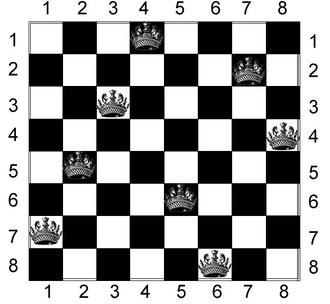

**Importante:** seguimos a indexação do Python. Portanto, a primeira coluna é a `0`, a segunda é a `1` e assim por diante. O mesmo vale para as linhas.

<details>
<summary>O que ganhamos ao representar o estado como uma lista, em vez de um tabuleiro completo 8x8?</summary>

Representar o estado como uma lista torna o problema muito mais simples de manipular computacionalmente. Em vez de guardar 64 posições do tabuleiro, guardamos apenas 8 valores, um para cada coluna. Isso reduz o custo de memória, facilita a geração de vizinhos e deixa o código mais legível. Além disso, como assumimos exatamente uma rainha por coluna, a lista já contém toda a informação importante para a busca local. Assim, mover uma rainha significa apenas alterar um número da lista, o que é muito mais prático do que reconstruir ou percorrer um tabuleiro completo a cada passo.

</details>

### Função de Objetivo

Para o Hill Climbing e para o Simulated Annealing, precisamos de uma função que diga o quão boa é uma configuração. Neste laboratório, vamos usar uma medida mais intuitiva: contar quantas rainhas estão **apaziguadas**, isto é, quantas não estão sendo atacadas por nenhuma outra. Quanto maior essa pontuação, melhor o estado. A solução ideal é aquela em que o valor chega a `8`.

In [2]:
def count_peaceful_queens(board):
    """Conta quantas rainhas nao atacam nenhuma outra rainha no tabuleiro."""
    peaceful_queens = 0
    n = len(board)

    for i in range(n):
        under_attack = False
        for j in range(n):
            if i == j:
                continue

            same_row = board[i] == board[j]
            same_diagonal = abs(i - j) == abs(board[i] - board[j])

            if same_row or same_diagonal:
                under_attack = True
                break

        if not under_attack:
            peaceful_queens += 1

    return peaceful_queens

<details>
<summary>Quais são as vantagens e limitações de usar “rainhas apaziguadas” como função objetivo?</summary>

A principal vantagem é a **intuição**. Quanto maior a pontuação, melhor o estado, e a solução ideal fica fácil de interpretar: queremos chegar a `8` rainhas apaziguadas. Isso costuma ser mais natural para os alunos do que pensar em minimizar conflitos. A limitação é que essa função objetivo não mede todos os estados intermediários com a mesma precisão possível de outras heurísticas. Dois tabuleiros diferentes podem ter a mesma quantidade de rainhas apaziguadas, mesmo que um deles esteja estruturalmente mais perto da solução final. Ou seja, a heurística é didática e útil, mas não necessariamente a mais informativa para todos os movimentos da busca.

</details>

<details>
<summary>Explicação</summary>

1. **def count_peaceful_queens(board):**
> Define a função que recebe a configuração do tabuleiro e retorna o total de rainhas "em paz" (seguras).

3. **peaceful_queens = 0**
> Inicializa o acumulador que contará cada rainha que não estiver sob ataque.

4. **n = len(board)**
> Identifica o tamanho do tabuleiro (número de rainhas).

6. **for i in range(n):**
> Inicia um loop para analisar cada rainha individualmente (cada coluna `i`).

7. **under_attack = False**
> Define um sinalizador (flag) assumindo que a rainha atual está segura até que se prove o contrário.

8. **for j in range(n):**
> Inicia um segundo loop para comparar a rainha atual `i` com todas as outras rainhas `j` do tabuleiro.

9. **if i == j: continue**
> Pula a comparação se a rainha for comparada com ela mesma.

12. **same_row = board[i] == board[j]**
> Verifica se a rainha `j` está na mesma linha que a rainha `i`. Se os valores forem iguais, as rainhas estão na mesma linha horizontal.

13. **same_diagonal = abs(i - j) == abs(board[i] - board[j])**
> Verifica se a rainha `j` está na mesma diagonal que a rainha `i` usando a diferença absoluta entre colunas e linhas. Se as distâncias forem idênticas, elas formam uma linha de 45 graus, caracterizando ataque diagonal.

15. **if same_row or same_diagonal:**
> Se houver conflito em linha ou diagonal, a rainha `i` não está "em paz".

16. **under_attack = True**
> Altera o sinalizador indicando que a rainha atual está sofrendo ataque.

17. **break**
> Interrompe o loop interno precocemente, pois não é necessário verificar outras rainhas se já sabemos que esta está sob ataque.

19. **if not under_attack:**
> Após verificar todas as outras rainhas, se o sinalizador continuar `False`, a rainha está segura.

20. **peaceful_queens += 1**
> Incrementa o contador de rainhas apaziguadas.

22. **return peaceful_queens**
> Retorna o total final. No cenário ideal, este valor será igual a `n`.

</details>

### Hill Climbing Padrão (inclinação máxima)

O Hill Climbing puro é como um alpinista com amnésia tentando escalar o Monte Everest sob um forte nevoeiro. Ele não consegue enxergar o topo da montanha nem lembrar por onde passou; apenas tateia o terreno imediatamente ao seu redor e dá o próximo passo na direção mais íngreme que encontrar. Se ele chegar ao topo de um pequeno morro, ele não encontra nenhum vizinho mais alto e para, achando que chegou ao cume absoluto, ignorando completamente que a verdadeira montanha pode estar logo ao lado.

In [3]:
def hill_climbing(num_queens):
    """Algoritmo de Hill Climbing maximizando rainhas apaziguadas."""

    current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]
    current_score = count_peaceful_queens(current_board)

    while True:
        best_neighbor_board = list(current_board)
        best_neighbor_score = current_score

        for col in range(num_queens):
            for new_row in range(num_queens):
                neighbor = list(current_board)
                neighbor[col] = new_row
                neighbor_score = count_peaceful_queens(neighbor)

                if neighbor_score > best_neighbor_score:
                    best_neighbor_score = neighbor_score
                    best_neighbor_board = neighbor

        if best_neighbor_score > current_score:
            current_board = best_neighbor_board
            current_score = best_neighbor_score
            print(f"Moving to: {current_board} | Peaceful queens: {current_score}")
        else:
            print("\nAlgorithm stopped. Local maximum or solution found.")
            return current_board, current_score

<details>
<summary>Explicação</summary>

1. **def hill_climbing(num_queens):**
> Define a função principal que tenta resolver o problema das rainhas usando otimização local.

4. **current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]**
> Gera um estado inicial aleatório, colocando uma rainha em cada coluna em uma linha sorteada.

5. **current_score = count_peaceful_queens(current_board)**
> Calcula a pontuação inicial (quantas rainhas estão seguras no tabuleiro aleatório).

7. **while True:**
> Inicia o loop de busca. O algoritmo continuará "subindo a encosta" até não encontrar mais melhorias.

8. **best_neighbor_board = list(current_board)**
> Cria uma cópia para armazenar o melhor movimento encontrado ao redor da posição atual.

11. **for col in range(num_queens):**
> Começa a explorar a vizinhança: percorre cada coluna do tabuleiro.

12. **for new_row in range(num_queens):**
> Para cada coluna, testa todas as outras linhas possíveis para a rainha.

14. **neighbor[col] = new_row**
> Cria um "vizinho" alterando a posição de apenas uma rainha.

15. **neighbor_score = count_peaceful_queens(neighbor)**
> Avalia quão boa é essa nova configuração sugerida.

17. **if neighbor_score > best_neighbor_score:**
> Se o vizinho for melhor que o melhor encontrado até agora nesta rodada, ele se torna a nova referência.

21. **if best_neighbor_score > current_score:**
> Após testar todos os vizinhos, verifica se o melhor deles é superior ao estado atual.

22. **current_board = best_neighbor_board**
> Se houver melhoria, o algoritmo "anda" para esse novo tabuleiro e continua a busca.

25. **else:**
> Se nenhum vizinho for melhor que o atual, o algoritmo atingiu um **máximo local** ou a solução ideal.

27. **return current_board, current_score**
> Encerra a execução devolvendo o melhor tabuleiro alcançado e sua pontuação.

</details>

### Hill Climbing Estocástico

O Hill Climbing puro é obcecado em pegar sempre o caminho mais íngreme disponível. O Hill Climbing Estocástico adiciona uma estratégia mais relaxada: o alpinista olha para todos os caminhos que levam para cima e escolhe um deles aleatoriamente, sendo que os caminhos mais inclinados têm apenas uma probabilidade maior de serem escolhidos. Sendo assim, a ideia é que, ao não ser estritamente ganancioso e perfeito em suas escolhas, o algoritmo converge um pouco mais devagar, mas tem muito mais chances de evitar caminhos enganosos e encontrar picos melhores na cordilheira.

In [4]:
def stochastic_hill_climbing(num_queens):
    """Hill Climbing Estocástico maximizando rainhas apaziguadas."""

    current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]
    current_score = count_peaceful_queens(current_board)

    while True:
        improving_neighbors = []
        improvements = []

        for col in range(num_queens):
            for new_row in range(num_queens):
                neighbor = list(current_board)
                neighbor[col] = new_row
                neighbor_score = count_peaceful_queens(neighbor)

                if neighbor_score > current_score:
                    improving_neighbors.append((neighbor, neighbor_score))
                    improvements.append(neighbor_score - current_score)

        if not improving_neighbors:
            print("\nAlgorithm stopped. Local maximum or solution found.")
            return current_board, current_score

        next_board, next_score = random.choices(
            improving_neighbors,
            weights=improvements,
            k=1,
        )[0]

        current_board = next_board
        current_score = next_score
        print(f"Moving to: {current_board} | Peaceful queens: {current_score}")

<details>
<summary>Em que sentido o Hill Climbing Estocástico é menos rígido do que o Hill Climbing padrão?</summary>

No *Hill Climbing* padrão, o algoritmo sempre escolhe o melhor vizinho disponível. Isso o torna totalmente determinístico e rígido em cada passo local, dado o estado atual. No *Hill Climbing* Estocástico, essa rigidez diminui porque ele não exige escolher sempre a subida mais íngreme. Em vez disso, ele lista todos os vizinhos que trazem alguma melhoria e sorteia um deles.

No código, a quebra dessa rigidez e o sorteio acontecem exatamente neste trecho:

```python
next_board, next_score = random.choices(
    improving_neighbors,
    weights=improvements,
    k=1,
)
```
Com o uso do comando `random.choices`, o algoritmo "gira uma roleta" para decidir o próximo passo. O parâmetro `weights=improvements` garante que a probabilidade de seleção varie de acordo com a inclinação da subida: movimentos que trazem uma melhoria maior ganham mais chances de serem sorteados, mas movimentos subótimos ainda mantêm uma probabilidade real de escolha. Assim, a busca continua “subindo”, mas com muito mais flexibilidade para explorar caminhos diferentes na paisagem de estados e evitar ficar presa rapidamente em máximos locais.
</details>

<details>
<summary>Explicação</summary>

1. **def stochastic_hill_climbing(num_queens):**
> Define a variante estocástica do Hill Climbing, que continua buscando melhorias locais, mas não escolhe sempre o melhor vizinho.

4. **current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]**
> Começa com um tabuleiro aleatório, como no Hill Climbing padrão.

8. **improving_neighbors = []**
> Cria uma lista para guardar apenas os vizinhos que realmente melhoram a solução atual.

9. **improvements = []**
> Guarda o tamanho da melhoria de cada vizinho, para que movimentos melhores tenham mais chance de serem escolhidos.

15. **neighbor_score = count_peaceful_queens(neighbor)**
> Avalia cada vizinho usando a mesma função objetivo do laboratório.

17. **if neighbor_score > current_score:**
> Filtra somente os vizinhos que sobem a encosta, isto é, os que aumentam o número de rainhas apaziguadas.

22. **if not improving_neighbors:**
> Se não existir nenhum vizinho melhor, o algoritmo parou em um máximo local ou chegou à solução ótima.

26. **random.choices(..., weights=improvements, k=1)**
> Sorteia um dos vizinhos melhores. Quanto maior a melhoria, maior a chance de ele ser escolhido.

32. **current_board = next_board**
> Move o algoritmo para o vizinho sorteado e continua a busca.

</details>

### Hill Climbing de Primeira Escolha

Agora, imagine que o nosso alpinista está em um terreno tão complexo que ele tem milhares de opções de passos possíveis ao seu redor. Avaliar todas elas para montar probabilidades (como na variante estocástica) demoraria muito. O Hill Climbing de Primeira Escolha adiciona uma estratégia de ganho de desempenho computacional: o alpinista simplesmente sorteia direções aleatórias uma por uma e, assim que encontra a *primeira* direção que o leva para cima, ele dá o passo. Sendo assim, a ideia é manter a aleatoriedade da subida, mas economizando processamento ao não precisar listar e avaliar todos os milhares de vizinhos antes de se mover.

In [5]:
def first_choice_hill_climbing(num_queens, max_attempts=100):
    """Hill Climbing de Primeira Escolha maximizando rainhas apaziguadas."""

    current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]
    current_score = count_peaceful_queens(current_board)

    while True:
        found_better_neighbor = False

        for _ in range(max_attempts):
            col = random.randint(0, num_queens - 1)
            new_row = random.randint(0, num_queens - 1)

            neighbor = list(current_board)
            neighbor[col] = new_row
            neighbor_score = count_peaceful_queens(neighbor)

            if neighbor_score > current_score:
                current_board = neighbor
                current_score = neighbor_score
                found_better_neighbor = True
                print(f"Moving to: {current_board} | Peaceful queens: {current_score}")
                break

        if not found_better_neighbor:
            print("\nAlgorithm stopped. Local maximum or solution found.")
            return current_board, current_score

<details>
<summary>O que o Hill Climbing de Primeira Escolha sacrifica e o que ele ganha em relação às outras variantes?</summary>

Ele ganha **velocidade de decisão**. Como não precisa avaliar toda a vizinhança, ele gera sucessores aleatoriamente apenas até encontrar o primeiro que seja melhor que o estado atual, o que é uma excelente estratégia quando o espaço de vizinhos é muito grande (por exemplo, milhares de sucessores). Por outro lado, ele sacrifica a **qualidade na escolha local**. Como aceita a primeira melhora encontrada, ele pode deixar passar movimentos muito melhores que apareceriam se ele examinasse mais opções. Em troca de eficiência computacional, ele abre mão de uma decisão local mais informada.

No código, essa característica central é perfeitamente representada pela condição de aceite seguida do comando `break`:

```python
if neighbor_score > current_score:
    current_board = neighbor
    current_score = neighbor_score
    found_better_neighbor = True
    
    # O comando break interrompe a busca cega instantaneamente
    break
```

É exatamente esse `break` que garante a **velocidade** (ao encerrar o laço de tentativas na mesma hora) e que impõe o **sacrifício da qualidade** (pois impede que o algoritmo continue testando outras combinações que poderiam gerar um `neighbor_score` ainda mais alto na mesma vizinhança).

</details>

<details>
<summary>Explicação</summary>

1. **def first_choice_hill_climbing(num_queens, max_attempts=100):**
> Define a variante de primeira escolha. Em vez de analisar toda a vizinhança, ela testa movimentos aleatórios até encontrar a primeira melhora.

4. **current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]**
> Gera um estado inicial aleatório.

8. **found_better_neighbor = False**
> Marca se, naquela rodada, algum vizinho melhor foi encontrado.

10. **for _ in range(max_attempts):**
> Limita quantas tentativas aleatórias serão feitas antes de desistir da rodada atual.

11. **col = random.randint(0, num_queens - 1)**
> Escolhe aleatoriamente uma coluna para mover uma rainha.

12. **new_row = random.randint(0, num_queens - 1)**
> Escolhe uma nova linha para essa rainha.

16. **neighbor_score = count_peaceful_queens(neighbor)**
> Avalia a qualidade do vizinho sorteado.

18. **if neighbor_score > current_score:**
> Se esse primeiro vizinho aleatório já for melhor, o algoritmo aceita o movimento imediatamente.

21. **break**
> Interrompe a busca local daquela rodada assim que encontra a primeira melhora.

23. **if not found_better_neighbor:**
> Se nenhuma melhora aparecer após várias tentativas, o algoritmo considera que ficou preso em um máximo local ou já chegou à solução ideal.

</details>

### Hill Climbing com Reinicio Aleatório

Finalmente, diferente do Hill Climbing puro onde o alpinista que só pode subir. O Hill Climbing com Reinício Aleatório adiciona uma estratégia simples, mas poderosa, para resolver esse problema. Se o algoritmo ficar preso em um máximo local, ele simplesmente "teletransporta" o alpinista para uma nova posição aleatória e começa a busca por um novo pico a partir dali. A ideia é que, ao reiniciar a busca várias vezes a partir de diferentes pontos de partida, a probabilidade de um desses inícios aleatórios levar ao máximo global (a solução ideal) aumenta drasticamente.

In [6]:
def random_restart_hill_climbing(num_queens, max_restarts=1000):
    """
    Resolve o problema das n rainhas usando Hill Climbing com reinício aleatório.
    Tenta encontrar uma solução com todas as rainhas apaziguadas.
    """
    restarts = 0
    while restarts < max_restarts:
        solution, score = hill_climbing(num_queens)

        if score == num_queens:
            print(f"Success! Solution found in {restarts + 1} attempts.")
            return solution, score

        restarts += 1
        print(f"Attempt {restarts} failed. Restarting...")

    print(f"\nFailure after {max_restarts} attempts.")
    return solution, score

<details>
<summary>Por que o Reinício Aleatório aumenta a chance de sucesso sem mudar a lógica local de busca?</summary>

Porque ele não altera o comportamento do Hill Climbing dentro de cada tentativa. A lógica local continua a mesma: subir enquanto houver melhora. O que muda é a **estratégia global**. Em vez de confiar em uma única posição inicial, o algoritmo experimenta vários pontos de partida diferentes. Isso aumenta a probabilidade de que pelo menos uma dessas tentativas comece em uma região mais favorável da paisagem de busca e consiga chegar à solução ideal.

</details>

<details>
<summary>Explicação</summary>

1. **def random_restart_hill_climbing(num_queens, max_restarts=1000):**
> Define a função que gerencia as múltiplas tentativas, aceitando o número de rainhas e um limite de reinícios.

7. **restarts = 0**
> Inicializa o contador de quantas vezes o algoritmo precisou começar do zero.

8. **while restarts < max_restarts:**
> Mantém o processo rodando enquanto a solução não for encontrada e o limite de tentativas não for atingido.

9. **solution, score = hill_climbing(num_queens)**
> Chama a função de busca local. Ela vai subir a "encosta" até onde conseguir e devolver o melhor tabuleiro que encontrou.

11. **if score == num_queens:**
> Verifica se a pontuação atingida é o máximo possível (todas as rainhas seguras).

13. **return solution, score**
> Se a solução for perfeita, encerra tudo imediatamente e retorna o resultado vitorioso.

15. **restarts += 1**
> Caso o Hill Climbing tenha ficado preso em um máximo local (score < num_queens), incrementa o contador de tentativas.

16. **print(f"Tentativa {restarts} falhou. Reiniciando...")**
> Avisa ao usuário que aquela "montanha" não era a correta e que uma nova posição aleatória será sorteada.

19. **return solution, score**
> Se o loop terminar sem sucesso, retorna a última solução encontrada (a melhor da última tentativa).

</details>

### Recozimento Simulado (Simulated Annealing)

O **Simulated Annealing** (Recozimento Simulado) é uma variante do *Hill Climbing* inspirada no processo metalúrgico de aquecimento e resfriamento gradual. O algoritmo utiliza o conceito de "temperatura" para guiar a busca: no início, com a temperatura alta, ele tem uma alta probabilidade de aceitar "passos ruins" (movimentos que pioram o estado atual). Essa tolerância ao erro funciona como um chacoalhão que permite ao algoritmo escapar de armadilhas e falsos picos (máximos locais). Conforme o processo avança, a temperatura diminui de forma controlada, reduzindo gradativamente a chance de aceitar pioras. Quando o sistema finalmente "esfria", ele passa a se comportar como o *Hill Climbing* tradicional, rejeitando erros e aceitando apenas melhorias até se estabilizar rigidamente na solução ideal (o máximo global).

Em resumo, a "temperatura" controla a probabilidade de aceitar um movimento que piora a solução.

* **Alta Temperatura:** O algoritmo tem uma alta probabilidade de aceitar um movimento que leva a um estado pior. Isso permite que ele "salte" para fora de máximos/mínimos locais e explore novas áreas da paisagem de busca.

* **Baixa Temperatura:** A probabilidade de aceitar um movimento ruim diminui. O algoritmo começa a se comportar de forma mais parecida com o Hill Climbing, concentrando-se em movimentos que melhoram a solução e se acomodando em um estado de baixa energia (poucos ataques).



In [7]:
def simulated_annealing(num_queens, initial_temp=100.0, cooling_rate=0.99, verbose=False):
    """Resolve o problema das n rainhas maximizando rainhas apaziguadas."""
    current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]
    current_score = count_peaceful_queens(current_board)
    temperature = initial_temp
    step = 0

    while temperature > 0.001:
        if verbose:
            print(f"Step {step} | Temperature: {temperature:.4f} | Peaceful queens: {current_score}")

        if current_score == num_queens:
            print("Success. Optimal solution was found.")
            return current_board, current_score

        neighbor = list(current_board)
        col_to_move = random.randint(0, num_queens - 1)
        new_row = random.randint(0, num_queens - 1)
        neighbor[col_to_move] = new_row
        neighbor_score = count_peaceful_queens(neighbor)

        delta_score = neighbor_score - current_score

        if delta_score > 0:
            current_board = neighbor
            current_score = neighbor_score
        else:
            probability = math.exp(delta_score / temperature)
            if random.random() < probability:
                current_board = neighbor
                current_score = neighbor_score

        temperature *= cooling_rate
        step += 1

    print("\nThe algorithm has stopped. The final state can be a local or global maximum.")
    return current_board, current_score

<details>
<summary>O que significa dizer que o Simulated Annealing equilibra exploração e refinamento?</summary>

Durante a busca, o algoritmo muda seu comportamento ao longo do tempo graças ao parâmetro de **temperatura**. No início, com a temperatura alta, ele atua na fase de **exploração**: aceita com facilidade movimentos piores (quedas na pontuação) para escapar de máximos locais e visitar novas regiões do espaço de busca. Conforme a temperatura cai gradualmente, ele entra na fase de **refinamento**: a tolerância a movimentos ruins diminui exponencialmente e a busca fica mais conservadora, comportando-se cada vez mais como o *Hill Climbing* tradicional, que foca apenas em melhorar a solução atual.

No código, esse equilíbrio dinâmico é perfeitamente ilustrado pelo bloco que calcula a probabilidade e pela atualização da temperatura:

```python
        # Se o movimento for ruim (delta_score <= 0), a matemática decide se o aceita
        else:
            probability = math.exp(delta_score / temperature)
            if random.random() < probability:
                current_board = neighbor
                current_score = neighbor_score

        # O cronograma de resfriamento faz a transição da exploração para o refinamento
        temperature *= cooling_rate
```

Quando a `temperature` é alta o algoritmo esta propenso a exploração. Em termos matematicos, isso faz com que a fração `delta_score / temperature` resulte em uma `probability` muito alta. O sorteio do `random.random()` frequentemente aceita o movimento ruim. Note que a linha `temperature *= cooling_rate` vai esfriando o sistema a cada iteração, i.e., o refinamento. Quando o `temperature` fica muito baixo, a `probability` encolhe para perto de zero, e o `if` passa a rejeitar as jogadas ruins, concentrando-se puramente em subir a encosta rumo à solução final.

A função decrita acima representa a expressão matemática correspondente a **distribuição de Boltzmann**, representada por:

**$e^{\Delta E / T}$**

*   **$e$**: é a base da função exponencial, representada no código por `math.exp`.
*   **$\Delta E$**: é a variação da pontuação (ou a medida da "ruindade" do movimento), representada no código por `delta_score`.
*   **$T$**: é a temperatura atual do sistema, representada no código por `temperature`.

</details>

<details>
<summary>Explicação</summary>

1. **def simulated_annealing(num_queens, initial_temp=100.0, cooling_rate=0.99, verbose=False):**
> Define a função que utiliza uma temperatura inicial, uma taxa de resfriamento e um parâmetro opcional de verbosidade para guiar a busca.

3. **current_board = [random.randint(0, num_queens - 1) for _ in range(num_queens)]**
> Começa com um tabuleiro totalmente aleatório.

6. **step = 0**
> Cria um contador de iterações para acompanhar a evolução da busca.

7. **while temperature > 0.001:**
> O loop principal continua enquanto o sistema ainda tiver "calor" suficiente para realizar mudanças.

8. **if verbose: print(...)**
> Quando `verbose=True`, a função mostra a iteração atual, a temperatura e a pontuação do estado, permitindo acompanhar o resfriamento durante a busca.

9. **if current_score == num_queens:**
> Se encontrar a solução perfeita (todas as rainhas apaziguadas), interrompe o processo imediatamente.

12. **neighbor = list(current_board)**
> Cria um vizinho alterando a posição de apenas uma rainha escolhida aleatoriamente.

18. **delta_score = neighbor_score - current_score**
> Calcula a diferença de qualidade. Se for positivo, o vizinho é melhor; se for negativo, o vizinho é pior.

20. **if delta_score > 0:**
> Regra de aceitação gananciosa: se o vizinho for melhor, ele é aceito imediatamente.

24. **else: probability = math.exp(delta_score / temperature)**
> O "pulo do gato": se o vizinho for pior, calcula-se uma probabilidade de aceitá-lo mesmo assim. Quanto maior a temperatura, mais provável é aceitar erros para explorar o mapa.

25. **if random.random() < probability:**
> Decide, através de um sorteio, se vai aceitar a solução pior para tentar escapar de um máximo local.

29. **temperature *= cooling_rate**
> Reduz a temperatura gradualmente. O algoritmo fica cada vez "mais exigente" e menos propenso a aceitar pioras.

30. **step += 1**
> Avança o contador de iterações para a próxima rodada da busca.

33. **return current_board, current_score**
> Retorna o melhor estado alcançado após o resfriamento completo.

</details>

### Visualizar tabuleiro

In [8]:
# @title Função para gerar tabuleiro
def print_board(board):
    """
    Gera e exibe uma representacao visual do tabuleiro de xadrez como uma imagem.

    Args:
        board (list): Uma lista de 8 posicoes, onde o indice e a coluna
                      e o valor e a linha da rainha.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    n = len(board)
    board_image = np.zeros((n, n, 3), dtype=np.uint8)

    # Define as cores dos quadrados do tabuleiro
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                board_image[i, j] = [255, 255, 255]  # Branco
            else:
                board_image[i, j] = [169, 169, 169]  # Cinza

    plt.imshow(board_image)

    # Desenha as rainhas
    for i in range(n):
        plt.text(i, n - 1 - board[i], '♕', ha='center', va='center', fontsize=20, color='black')

    # Adiciona titulos e rotulos
    plt.title("Tabuleiro de Xadrez com 8 Rainhas")
    plt.xticks(np.arange(n))
    plt.yticks(np.arange(n), labels=np.arange(n-1, -1, -1))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

## Exemplo prático

### Cenário 1 - Hill Climbing padrão

Neste cenário, vamos executar o **Hill Climbing padrão**. O algoritmo começa em um tabuleiro aleatório, avalia todos os vizinhos possíveis em cada passo e sempre escolhe o melhor deles. Se não existir vizinho melhor, a execução para, mesmo que a solução ideal ainda não tenha sido encontrada.

In [9]:
solution, score = hill_climbing(8)
print("\nFinal Solution:")
print(f"Board: {solution}")
print(f"Peaceful queens: {score}")

if score == 8:
    print("Success! Solution found.")
else:
    print("Failure! Stuck at a local maximum.")

Moving to: [1, 2, 5, 3, 5, 7, 4, 1] | Peaceful queens: 3
Moving to: [1, 2, 5, 3, 0, 7, 4, 1] | Peaceful queens: 5
Moving to: [5, 2, 5, 3, 0, 7, 4, 1] | Peaceful queens: 6

Algorithm stopped. Local maximum or solution found.

Final Solution:
Board: [5, 2, 5, 3, 0, 7, 4, 1]
Peaceful queens: 6
Failure! Stuck at a local maximum.


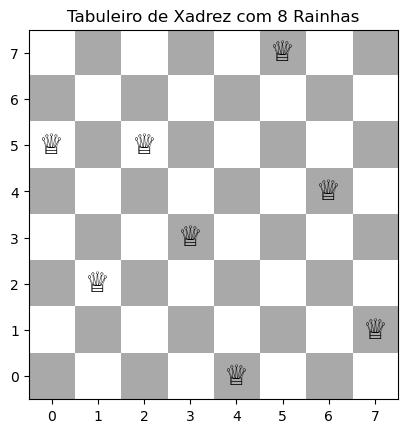

In [10]:
print_board(solution)

<details>
<summary>O que observar neste resultado?</summary>

No Hill Climbing padrão, não existe garantia de sucesso em toda execução. Se o algoritmo parar com menos de `8` rainhas apaziguadas, isso significa que ele ficou preso em um **máximo local**. Se chegar a `8`, então encontrou uma solução válida do problema.

</details>

### Cenário 2 - Hill Climbing Estocástico

Agora vamos executar o **Hill Climbing Estocástico**. Diferentemente da versão padrão, ele não escolhe sempre o melhor vizinho. Em cada rodada, ele reúne todos os vizinhos que melhoram o estado atual e sorteia um deles, dando maior chance para as melhorias maiores.

In [35]:
stochastic_solution, stochastic_score = stochastic_hill_climbing(8)
print("\nFinal Solution:")
print(f"Board: {stochastic_solution}")
print(f"Peaceful queens: {stochastic_score}")

if stochastic_score == 8:
    print("Success! Solution found.")
else:
    print("Failure! Stuck at a local maximum.")

Moving to: [3, 1, 3, 3, 0, 7, 1, 4] | Peaceful queens: 3
Moving to: [3, 5, 3, 3, 0, 7, 1, 4] | Peaceful queens: 4
Moving to: [3, 5, 3, 6, 0, 7, 1, 4] | Peaceful queens: 5
Moving to: [2, 5, 3, 6, 0, 7, 1, 4] | Peaceful queens: 6

Algorithm stopped. Local maximum or solution found.

Final Solution:
Board: [2, 5, 3, 6, 0, 7, 1, 4]
Peaceful queens: 6
Failure! Stuck at a local maximum.


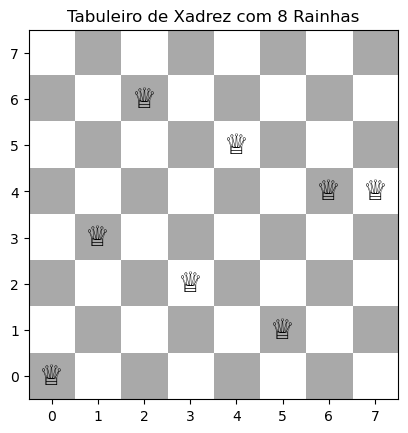

In [12]:
print_board(stochastic_solution)

### Cenário 3 - Hill Climbing de Primeira Escolha

Neste cenário, vamos testar o **Hill Climbing de Primeira Escolha**. Em vez de analisar toda a vizinhança, o algoritmo sorteia movimentos aleatórios e aceita imediatamente o primeiro que melhora a solução atual. Isso torna a execução mais leve, mas também mais dependente do acaso.

In [45]:
first_choice_solution, first_choice_score = first_choice_hill_climbing(8)
print("\nFinal Solution:")
print(f"Board: {first_choice_solution}")
print(f"Peaceful queens: {first_choice_score}")

if first_choice_score == 8:
    print("Success! Solution found.")
else:
    print("Failure! Stuck at a local maximum.")

Moving to: [2, 4, 6, 4, 3, 1, 3, 5] | Peaceful queens: 4
Moving to: [2, 4, 6, 4, 7, 1, 3, 5] | Peaceful queens: 5
Moving to: [2, 0, 6, 4, 7, 1, 3, 5] | Peaceful queens: 8

Algorithm stopped. Local maximum or solution found.

Final Solution:
Board: [2, 0, 6, 4, 7, 1, 3, 5]
Peaceful queens: 8
Success! Solution found.


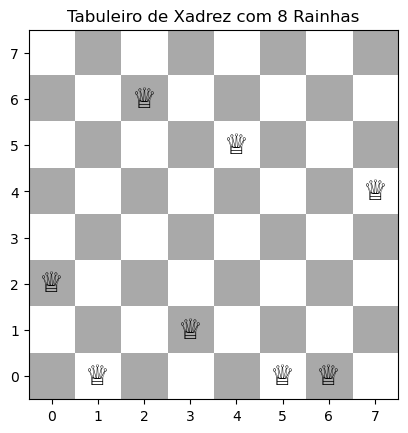

In [14]:
print_board(first_choice_solution)

### Cenário 4 - Hill Climbing com Reinício Aleatório

Agora vamos executar o **Hill Climbing com Reinício Aleatório**. A cada tentativa, o algoritmo roda o Hill Climbing padrão a partir de um novo estado inicial aleatório. Se uma execução ficar presa em máximo local, outra tentativa é iniciada até encontrar uma solução ou atingir o número máximo de reinícios.

In [50]:
final_solution, final_score = random_restart_hill_climbing(8)
print("\nSolucao Final:")
print(f"Tabuleiro: {final_solution}")
print(f"Rainhas apaziguadas: {final_score}")


Algorithm stopped. Local maximum or solution found.
Attempt 1 failed. Restarting...
Moving to: [2, 5, 7, 4, 4, 3, 4, 6] | Peaceful queens: 4
Moving to: [2, 5, 7, 0, 4, 3, 4, 6] | Peaceful queens: 5
Moving to: [2, 5, 7, 0, 4, 3, 1, 6] | Peaceful queens: 6

Algorithm stopped. Local maximum or solution found.
Attempt 2 failed. Restarting...
Moving to: [6, 1, 7, 2, 5, 3, 3, 3] | Peaceful queens: 3
Moving to: [6, 1, 7, 2, 5, 3, 3, 0] | Peaceful queens: 4
Moving to: [6, 1, 7, 2, 5, 3, 7, 0] | Peaceful queens: 5

Algorithm stopped. Local maximum or solution found.
Attempt 3 failed. Restarting...
Moving to: [7, 0, 7, 3, 0, 7, 4, 0] | Peaceful queens: 2
Moving to: [7, 2, 7, 3, 0, 7, 4, 0] | Peaceful queens: 3
Moving to: [7, 2, 7, 3, 0, 7, 4, 1] | Peaceful queens: 5

Algorithm stopped. Local maximum or solution found.
Attempt 4 failed. Restarting...
Moving to: [1, 6, 2, 6, 4, 7, 3, 6] | Peaceful queens: 2
Moving to: [1, 6, 0, 6, 4, 7, 3, 6] | Peaceful queens: 4
Moving to: [1, 5, 0, 6, 4, 7, 3, 

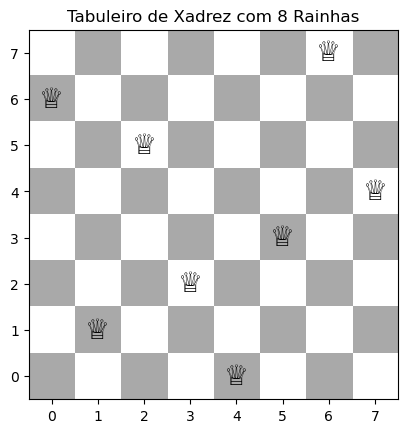

In [16]:
print_board(final_solution)

### Cenário 5 - Simulated Annealing

Por fim, vamos executar o **Simulated Annealing** em seu modo normal. Esse algoritmo começa em um estado aleatório e pode aceitar movimentos que pioram temporariamente a solução. Conforme a temperatura diminui, a busca fica mais conservadora e passa a refinar a melhor região encontrada.

In [55]:
annealing_solution, annealing_score = simulated_annealing(8)
print("\nFinal Solution:")
print(f"Board configuration: {annealing_solution}")
print(f"Peaceful queens: {annealing_score}")


The algorithm has stopped. The final state can be a local or global maximum.

Final Solution:
Board configuration: [7, 3, 1, 3, 5, 0, 2, 4]
Peaceful queens: 6


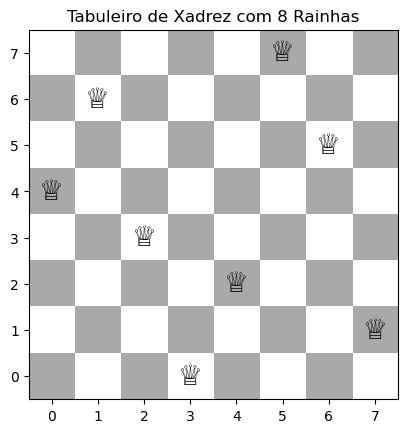

In [18]:
print_board(annealing_solution)

<details>
<summary>O que observar neste resultado?</summary>

No Simulated Annealing, a solução pode melhorar mesmo depois de aceitar alguns movimentos piores ao longo do caminho. Isso acontece porque o algoritmo usa a temperatura para equilibrar exploração e refinamento. Se chegar a `8`, encontrou uma solução válida; se parar antes disso, terminou o processo de resfriamento sem alcançar o ótimo global.

</details>

### Cenário 6 - Simulated Annealing com verbose

Neste cenário, vamos executar novamente o **Simulated Annealing**, mas agora com `verbose=True`. Assim, além do resultado final, será possível acompanhar a temperatura diminuindo durante a busca e observar como o algoritmo vai ficando menos exploratório a cada iteração.

In [19]:
verbose_solution, verbose_score = simulated_annealing(8, verbose=True)
print("\nFinal Solution:")
print(f"Board configuration: {verbose_solution}")
print(f"Peaceful queens: {verbose_score}")

Step 0 | Temperature: 100.0000 | Peaceful queens: 0
Step 1 | Temperature: 99.0000 | Peaceful queens: 0
Step 2 | Temperature: 98.0100 | Peaceful queens: 1
Step 3 | Temperature: 97.0299 | Peaceful queens: 1
Step 4 | Temperature: 96.0596 | Peaceful queens: 0
Step 5 | Temperature: 95.0990 | Peaceful queens: 1
Step 6 | Temperature: 94.1480 | Peaceful queens: 1
Step 7 | Temperature: 93.2065 | Peaceful queens: 1
Step 8 | Temperature: 92.2745 | Peaceful queens: 1
Step 9 | Temperature: 91.3517 | Peaceful queens: 1
Step 10 | Temperature: 90.4382 | Peaceful queens: 1
Step 11 | Temperature: 89.5338 | Peaceful queens: 1
Step 12 | Temperature: 88.6385 | Peaceful queens: 0
Step 13 | Temperature: 87.7521 | Peaceful queens: 1
Step 14 | Temperature: 86.8746 | Peaceful queens: 0
Step 15 | Temperature: 86.0058 | Peaceful queens: 1
Step 16 | Temperature: 85.1458 | Peaceful queens: 0
Step 17 | Temperature: 84.2943 | Peaceful queens: 0
Step 18 | Temperature: 83.4514 | Peaceful queens: 0
Step 19 | Temperature

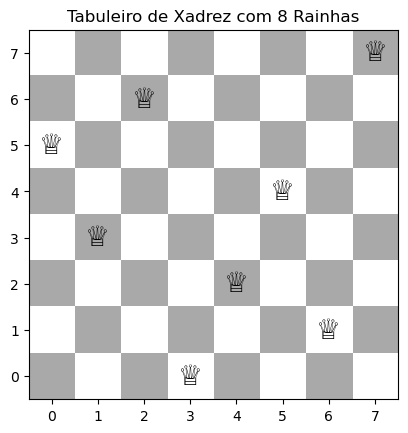

In [20]:
print_board(verbose_solution)

<details>
<summary>Por que a temperatura está caindo?</summary>

A temperatura cai devido a queda na pontuação. A queda na temperatura atua como a medida de "ruindade" do movimento e afeta a chance de aceitação de forma direta: **quanto maior for a queda (o tamanho do prejuízo), menor será a probabilidade de o algoritmo aceitar esse passo ruim**. Matematicamente, a fórmula ($e^{\Delta E / T}$) utiliza essa diferença negativa para reduzir a probabilidade de forma exponencial, o que significa que pequenas pioras têm grandes chances de serem perdoadas, mas pioras muito severas reduzem a probabilidade drasticamente. No entanto, o algoritmo sempre divide essa queda pela "Temperatura" atual, que funciona como um amortecedor: se a temperatura estiver alta (no início da busca), ela suaviza o impacto do tombo, permitindo que o sistema engula o prejuízo e aceite até mesmo os movimentos muito ruins para conseguir explorar novas rotas.

</details>

## Key Takeaways

*   **Compreensão da Busca Local:** Entender que algoritmos de busca local operam avaliando estados vizinhos com o objetivo de encontrar a melhor configuração final (máximo ou mínimo global) de acordo com uma função objetivo, sem se preocupar com o caminho percorrido para chegar até lá.
*   **Flexibilidade da Função Objetivo:** Aprender que a modelagem do problema pode ser adaptada para facilitar a interpretação heurística. No problema das 8 rainhas, por exemplo, o ótimo global é alcançado maximizando o placar para 8 rainhas apaziguadas, em vez de minimizar os ataques.
*   **Limitações do *Hill Climbing* Puro:** Reconhecer que a Subida de Encosta tradicional é um algoritmo estritamente "guloso" (*greedy*), que só aceita movimentos que melhorem imediatamente o estado atual, o que frequentemente o deixa preso em armadilhas como os máximos locais.
*   **Estratégias de Fuga com Reinício Aleatório:** Avaliar como a variante *Random-Restart Hill Climbing* mitiga o problema dos falsos picos, reiniciando a busca a partir de posições iniciais aleatórias sempre que estagnar, aumentando drasticamente a probabilidade de sucesso.
*   **A Intuição Termodinâmica do *Simulated Annealing*:** Compreender que o Recozimento Simulado introduz uma exploração probabilística baseada em "temperatura", permitindo que o algoritmo aceite temporariamente movimentos "ruins" (quedas na pontuação) para conseguir escapar das armadilhas dos máximos locais.
*   **Mecânica da Regra de Aceitação:** Dominar a lógica matemática de avaliação dos vizinhos, onde $\Delta$ representa a diferença de pontuação ($\Delta = \text{score}_{vizinho} - \text{score}_{atual}$):
    *   Movimentos de melhoria ($\Delta > 0$) são sempre aceitos imediatamente.
    *   Movimentos de piora ($\Delta < 0$) são aceitos com base na probabilidade gerada pela fórmula de Boltzmann: $P = e^{\Delta/T}$.
*   **O Papel do Cronograma de Resfriamento:** Entender na prática como o parâmetro "Temperatura" ($T$) atua ao longo do tempo. Uma temperatura alta no início promove a exploração livre ao aceitar muitos erros; conforme a busca avança e a temperatura cai, o algoritmo perde essa tolerância e foca no refinamento rigoroso da solução encontrada.

## Referências

1. Russell, S. & Norvig, P. (2010). *Artificial Intelligence: A Modern Approach*. Prentice Hall.
2. Wikipedia: Hill-climbing algorithm.
3. Wikipedia: Simulated annealing.
4. GeeksforGeeks: N-Queen Problem using Hill Climbing.